In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
from FigS6_coding_model_fanofactor import *

(931, 400)


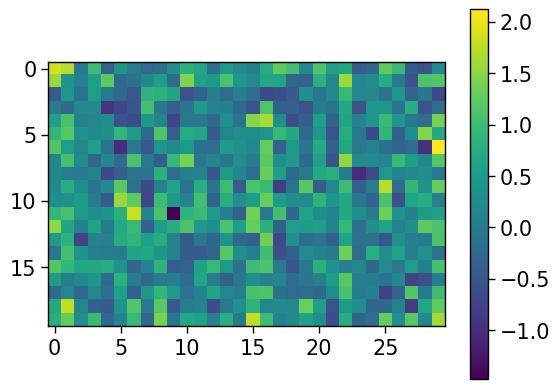

In [ ]:
# generate glomerular responses
N = 20 # sqrt num glomeruli
rho = 0.5 # antagonism correlation
conc = train_cue_conc = bg_conc = 1e-3 # 1e0
b = 18 # total number of odors (cue + bg combined)
n_bg = b - 2
sigma = 0.4 # gaussian noise strength
cue = -1 # random targets
model_params = init_model_parameters(total_bg=n_bg, N=N, rho=rho, bg_conc=conc, F_max=1, n=4, train_cue_conc=conc)
n_train = 1000

F_max = model_params['F_max']
n = model_params['n']
lneta = model_params['lneta']
kappa = model_params['kappa']
total_bg = model_params['total_bg']
inv_kappa = 1.0 / kappa
eta = np.exp(lneta)


X_train_odor, y_train = generate_odor_vecs_vectorized(n_train, train_cue_conc, bg_conc, cue=cue, n_bg=-1, total_bg=total_bg)
X_train_odor[:, :2] = 0 # remove cue odors
X_train_odor = X_train_odor[X_train_odor.sum(axis=1) > 0] # remove empty rows
n_train = X_train_odor.shape[0]

X_train_tensor = tensorize_concs(X_train_odor, n_train, b, N)
train_responses = compute_activity_vec(X_train_tensor, kappa, eta, F_max, n, sigma, inv_kappa=inv_kappa)
X_train = train_responses.reshape(n_train, -1)

print(X_train.shape)

plt.figure()
plt.imshow(X_train[:20, :30])
plt.colorbar()

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def ridge_logistic_cv(df: pd.DataFrame,
                      one_hot_indices: np.ndarray,
                      C: float = 1.0,
                      n_splits: int = 5,
                      random_state: int = 42) -> pd.DataFrame:
    """
    Runs n_splits‐fold stratified CV of an L2‐penalized logistic regression
    for each odor (binary: odor vs. all others).
    
    Returns a DataFrame with per‐odor mean & std accuracy.
    """
    # if df.shape[1] > 120:
    #     df = df.sample(n=120, axis=1, random_state=random_state, replace=False) # limit to 120 neurons for fair comparison

    X = df.values                          # shape (n_samples, n_features)
    print(f'X.shape: {X.shape}')
    n_odors = one_hot_indices.shape[1]
    results = []
    
    # ensure we have at least two classes present for each odor
    for odor in range(n_odors):
        y = one_hot_indices[:, odor]
        # skip if odor never present or always present
        if y.sum() == 0 or y.sum() == len(y):
            print(f"Skipping odor {odor}: only one class present.")
            continue
        
        skf = StratifiedKFold(n_splits=n_splits,
                              shuffle=True,
                              random_state=random_state)
        clf = LogisticRegression(penalty='l2',
                                 C=C,
                                 solver='liblinear',
                                 random_state=random_state)
        
        scores = cross_val_score(clf,
                                 X,
                                 y,
                                 cv=skf,
                                 scoring='accuracy',
                                 n_jobs=n_splits)
        
        results.append({
            'odor': odor,
            'mean_accuracy': scores.mean(),
            'std_accuracy': scores.std(),
            'all_scores': scores
        })
        # print(f'Odor={odor}, mean_acc={scores.mean():.4f}, std_acc={scores.std():.4f}, go_size={int(np.sum(y))}/{len(y)}')
    
    return pd.DataFrame(results)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from numpy.random import SeedSequence

# -------------------------
# Helper: one task (f, N_c_factor)
# -------------------------
def _run_one_sweep(N, X_train, X_train_odor, f, N_c_factor, base_seed=42):
    """
    Returns a cv_df tagged with f, N_c, N_c_factor.
    Uses an independent RNG per (f, N_c_factor) for reproducibility.
    """
    # independent seed per task
    ss = SeedSequence(base_seed)
    task_seed = ss.spawn(1 + int(1000 * f) + 10_000 * N_c_factor)[0].generate_state(1)[0]
    rng = np.random.default_rng(task_seed)

    N_c = N_c_factor * (N ** 2)

    # Expansion + sparsification
    W_expansive = rng.normal(0, 2 / np.sqrt(N**2), size=(N_c, N**2))
    X_train_expanded = (W_expansive @ X_train.T).T  # n_train x N_c
    T = np.percentile(X_train_expanded, 100 - f * 100)
    X_train_expanded = np.maximum(0, X_train_expanded - T)

    cortex_resp_df = pd.DataFrame(X_train_expanded)

    # Your CV classifier (must exist in your env)
    cv_df = ridge_logistic_cv(cortex_resp_df, X_train_odor > 0)

    # Normalize accuracy column name
    cv_df = cv_df.copy()
    if "mean_accuracy" in cv_df.columns:
        cv_df["acc"] = cv_df["mean_accuracy"]
    elif "acc" not in cv_df.columns:
        raise ValueError("Expected an 'accuracy' column in cv_df (or 'acc').")

    # Tag metadata
    cv_df["f"] = f
    cv_df["N_c"] = N_c
    cv_df["N_c_factor"] = N_c_factor
    return cv_df

# -------------------------
# Configure sweeps
# -------------------------
f_list = [0.001, 0.01, 0.05, 0.1, 0.2] #, 1.0]
Nc_factors = [1, 5, 10, 50, 100]

tasks = [(f, fac) for f in f_list for fac in Nc_factors]

# -------------------------
# LAZY PARALLEL EXECUTION
# -------------------------
n_jobs = -1  # use all cores
backend = "loky"  # process-based; switch to "threading" if memory is tight
pre_dispatch = "2*n_jobs"  # stream tasks in small waves to limit RAM
batch_size = "auto"

# Try streaming generator mode if available in your joblib
use_generator = False
try:
    # Joblib >= ~1.3–1.4 supports return_as="generator"
    par = Parallel(
        n_jobs=n_jobs,
        backend=backend,
        batch_size=batch_size,
        pre_dispatch=pre_dispatch,
        return_as="generator",
    )
    gen = par(delayed(_run_one_sweep)(N, X_train, X_train_odor, f, fac)
              for (f, fac) in tasks)
    use_generator = True
except TypeError:
    # Fallback: no generator support, but still parallel and streamed internally
    par = Parallel(
        n_jobs=n_jobs,
        backend=backend,
        batch_size=batch_size,
        pre_dispatch=pre_dispatch,
    )
    results_list = par(delayed(_run_one_sweep)(N, X_train, X_train_odor, f, fac)
                       for (f, fac) in tasks)

# -------------------------
# Collect results
# -------------------------
clf_dfs = []
if use_generator:
    for cv_df in gen:   # consume lazily as tasks finish
        clf_dfs.append(cv_df)
else:
    clf_dfs = results_list

# -------------------------
# Special case: baseline with no expansion (N_c=0.0) and f=1.0
# Fit classifier directly on raw X_train
# -------------------------
baseline_cv_df = ridge_logistic_cv(pd.DataFrame(X_train), X_train_odor > 0).copy()
if "mean_accuracy" in baseline_cv_df.columns:
    baseline_cv_df["acc"] = baseline_cv_df["mean_accuracy"]
elif "acc" not in baseline_cv_df.columns:
    raise ValueError("Expected an 'accuracy' column in baseline_cv_df (or 'acc').")

baseline_cv_df["f"] = 1.0
baseline_cv_df["N_c"] = 0.0
baseline_cv_df["N_c_factor"] = 0
baseline_mean_acc = float(baseline_cv_df["acc"].mean())

# Add baseline to the pool
clf_dfs.append(baseline_cv_df)

all_df = pd.concat(clf_dfs, ignore_index=True)

# -------------------------
# Aggregate (mean ± std across 16 classifications per (f, N_c))
# -------------------------
agg = (
    all_df.groupby(["f", "N_c", "N_c_factor"])["acc"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values(["f", "N_c"])
)


X.shape: (931, 400)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 400)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 400)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 2000)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 2000)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 2000)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 400)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 4000)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 4000)
Skipping odor 0: only one class present.
Skipping odor 1: only one class present.
X.shape: (931, 4000)
Skipping odor 0: only one class present.
Skipping odor 1

In [10]:
agg

,f,N_c,N_c_factor,mean,std,count
0,0.001,400.0,1,0.600702,0.029456,16
1,0.001,2000.0,5,0.697021,0.015404,16
2,0.001,4000.0,10,0.729043,0.019289,16
3,0.001,20000.0,50,0.784234,0.023479,16
4,0.001,40000.0,100,0.814703,0.024413,16
5,0.010,400.0,1,0.732262,0.028963,16
6,0.010,2000.0,5,0.820542,0.023354,16
7,0.010,4000.0,10,0.852235,0.025950,16
8,0.010,20000.0,50,0.920444,0.022288,16
9,0.010,40000.0,100,0.937634,0.016551,16


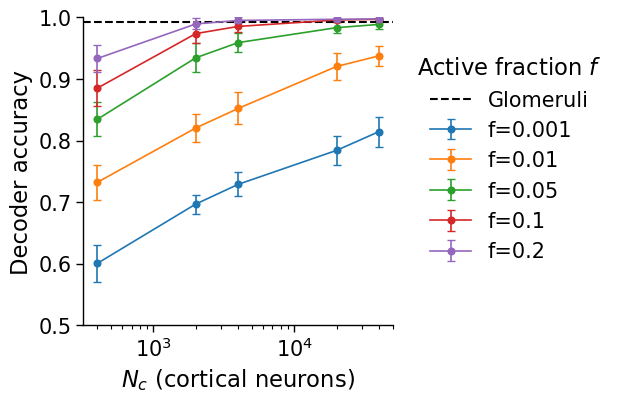

In [11]:
# -------------------------
# Plot
# -------------------------
sns.set_context("paper", font_scale=1.7)
plt.figure(figsize=(4, 4))
for f, sub in agg.groupby("f"):
    sub = sub.sort_values("N_c")
    if f != 1.0:
        plt.errorbar(
            sub["N_c"],
            sub["mean"],
            yerr=sub["std"],
            marker="o",
            capsize=3,
            linestyle="-",
            label=f"f={f}",
        )

# Horizontal baseline at raw X accuracy (f=1.0, N_c=0)
plt.axhline(y=baseline_mean_acc, color='black', linestyle="--", linewidth=1.5,
            label=f"Glomeruli")
if N < 25:
    plt.ylim(0.5, 1)
else:
    plt.ylim(0.6, 1)

plt.xlabel(r"$N_c$ (cortical neurons)")
plt.ylabel("Decoder accuracy")
plt.xscale("log")  # comment out if you prefer linear

# Move legend outside the figure, on the right
plt.legend(title="Active fraction $f$", bbox_to_anchor=(1.05, 0.9), loc="upper left", borderaxespad=0., frameon=False)
sns.despine()
plt.savefig(f'../figures/manuscript/SI9A_expansive_code_N_glom={N**2}.png', dpi=600, bbox_inches='tight')
plt.savefig(f'../figures/manuscript/SI9A_expansive_code_N_glom={N**2}.svg', dpi=600, bbox_inches='tight')